In [4]:
#Cell 1: Imports

import os
import shutil
import zipfile
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, precision_recall_fscore_support
from google.colab import drive

warnings.filterwarnings('ignore')
print("Imports successful.")
print(f"TensorFlow version: {tf.__version__}")

Imports successful.
TensorFlow version: 2.19.0


In [5]:
#Cell 2: Configuration Parameters

GDRIVE_ZIP_PATH = '/content/drive/MyDrive/AD_Dataset_compressed.zip'
LOCAL_ZIP_PATH = '/content/Data.zip'
LOCAL_UNZIP_DIR = '/content/Data'
DATA_DIR = '/content/Data/AD Datasets/Data'

# InceptionV3 optimal input size is 299x299 (not 224x224)
IMG_SIZE = (299, 299)
BATCH_SIZE = 128  # Smaller batch size for InceptionV3 (memory intensive)
NUM_CLASSES = 4

# Two-stage training parameters
LR_HEAD = 1e-4      # Learning rate for head training
LR_FINETUNE = 1e-4  # Learning rate for fine-tuning
EPOCHS_HEAD = 50    # Epochs for training head only
EPOCHS_FINETUNE = 50  # Epochs for fine-tuning

SEED = 42
BEST_MODEL_SAVE_PATH = '/content/drive/MyDrive/inceptionv3_best.keras'
AUTOTUNE = tf.data.AUTOTUNE

print("Configuration parameters set.")
print(f"Mode: INCEPTION V3 TRANSFER LEARNING")
print(f"Image Size: {IMG_SIZE} (optimal for InceptionV3)")


Configuration parameters set.
Mode: INCEPTION V3 TRANSFER LEARNING
Image Size: (299, 299) (optimal for InceptionV3)


In [6]:
#Cell 3: Mount Google Drive & Extract Dataset

drive.mount('/content/drive', force_remount=True)

if not os.path.exists(GDRIVE_ZIP_PATH):
    raise FileNotFoundError(f"Zip file not found at {GDRIVE_ZIP_PATH}")

if not os.path.exists(DATA_DIR):
    print(f"Copying {GDRIVE_ZIP_PATH} to local storage...")
    shutil.copyfile(GDRIVE_ZIP_PATH, LOCAL_ZIP_PATH)

    if os.path.exists(LOCAL_UNZIP_DIR):
        shutil.rmtree(LOCAL_UNZIP_DIR)
    os.makedirs(LOCAL_UNZIP_DIR)

    print(f"Extracting {LOCAL_ZIP_PATH}...")
    with zipfile.ZipFile(LOCAL_ZIP_PATH, 'r') as z:
        z.extractall(LOCAL_UNZIP_DIR)
else:
    print("Data already extracted.")

if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(f"Expected data directory not found at {DATA_DIR}")

print("Dataset ready.")


Mounted at /content/drive
Copying /content/drive/MyDrive/AD_Dataset_compressed.zip to local storage...
Extracting /content/Data.zip...
Dataset ready.


In [7]:
#Cell 4: Load Dataset & Split (80/10/10)

full_dataset = image_dataset_from_directory(
    DATA_DIR,
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

class_names = full_dataset.class_names
print("Classes found:", class_names)

total_batches = tf.data.experimental.cardinality(full_dataset).numpy()
train_batches = int(total_batches * 0.8)
val_batches = int(total_batches * 0.1)
test_batches = total_batches - train_batches - val_batches

# Ensure at least 1 batch for val and test
if val_batches == 0 and total_batches > train_batches:
    val_batches = 1
if test_batches == 0 and total_batches > train_batches + val_batches:
    test_batches = 1
train_batches = total_batches - val_batches - test_batches

train_dataset = full_dataset.take(train_batches)
val_and_test = full_dataset.skip(train_batches)
val_dataset = val_and_test.take(val_batches)
test_dataset = val_and_test.skip(val_batches)

print(f"\nDataset splits:")
print(f"Total batches: {total_batches}")
print(f"Training batches: {train_batches}")
print(f"Validation batches: {val_batches}")
print(f"Test batches: {test_batches}")


Found 86437 files belonging to 4 classes.
Classes found: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']

Dataset splits:
Total batches: 676
Training batches: 540
Validation batches: 67
Test batches: 69


In [8]:
#Cell 5: Data Preprocessing & Augmentation

# InceptionV3 preprocessing: scales to [-1, 1]
def inception_preprocess(image, label):
    return tf.keras.applications.inception_v3.preprocess_input(image), label

# Data augmentation pipeline
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

# Apply preprocessing and augmentation
train_dataset_processed = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
)
train_dataset_processed = train_dataset_processed.map(
    inception_preprocess,
    num_parallel_calls=AUTOTUNE
)

val_dataset_processed = val_dataset.map(
    inception_preprocess,
    num_parallel_calls=AUTOTUNE
)

test_dataset_processed = test_dataset.map(
    inception_preprocess,
    num_parallel_calls=AUTOTUNE
)

# Cache and prefetch for performance
train_dataset_processed = train_dataset_processed.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset_processed = val_dataset_processed.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset_processed = test_dataset_processed.cache().prefetch(buffer_size=AUTOTUNE)

print("Data preprocessing and augmentation configured.")


Data preprocessing and augmentation configured.


In [9]:
#Cell 6: Define Improved Focal Loss Function

def focal_loss_fn(alpha=0.75, gamma=3.0):
    """
    Improved Focal Loss for handling class imbalance.
    alpha: increased to 0.75 to help minority classes
    gamma: increased to 3.0 to heavily penalize easy examples (majority class)
    """
    def focal_loss(y_true, y_pred):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=NUM_CLASSES)
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0 - 1e-8)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        loss = tf.reduce_sum(weight * cross_entropy, axis=1)
        return tf.reduce_mean(loss)
    return focal_loss

print("Improved Focal Loss function defined (alpha=0.75, gamma=3.0)")


Improved Focal Loss function defined (alpha=0.75, gamma=3.0)


In [10]:
#Cell 7: Build InceptionV3 Model

print("Building InceptionV3 with Transfer Learning...")

# Base model with ImageNet weights
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False  # Freeze for Stage 1

# Build custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

print(f"Total trainable parameters (Stage 1): {sum([tf.size(w).numpy() for w in model.trainable_weights])}")
model.summary()


Building InceptionV3 with Transfer Learning...
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Total trainable parameters (Stage 1): 2628100


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 24,433,956 (93.21 MB)

 Trainable params: 2,628,100 (10.03 MB)

 Non-trainable params: 21,805,856 (83.18 MB)

In [11]:
#Cell 8: STAGE 1 - Train Head (Frozen Base)

print("\n" + "="*80)
print("STAGE 1: Training Head (Frozen Base Model)")
print("="*80)

model.compile(
    optimizer=Adam(learning_rate=LR_HEAD),
    loss=focal_loss_fn(alpha=0.75, gamma=3.0),
    metrics=['accuracy']
)

checkpoint_stage1 = ModelCheckpoint(
    '/content/drive/MyDrive/inceptionv3_stage1_best.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop_stage1 = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler_stage1 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

history1 = model.fit(
    train_dataset_processed,
    epochs=EPOCHS_HEAD,
    validation_data=val_dataset_processed,
    callbacks=[checkpoint_stage1, early_stop_stage1, lr_scheduler_stage1],
    verbose=1
)

print("\nStage 1 (Head Training) Complete!")



STAGE 1: Training Head (Frozen Base Model)
Epoch 1/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.3928 - loss: 0.7799
Epoch 1: val_loss improved from inf to 0.15697, saving model to /content/drive/MyDrive/inceptionv3_stage1_best.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 261s 422ms/step - accuracy: 0.3929 - loss: 0.7796 - val_accuracy: 0.7792 - val_loss: 0.1570 - learning_rate: 1.0000e-04
Epoch 2/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6418 - loss: 0.3068
Epoch 2: val_loss improved from 0.15697 to 0.13807, saving model to /content/drive/MyDrive/inceptionv3_stage1_best.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 44s 81ms/step - accuracy: 0.6419 - loss: 0.3067 - val_accuracy: 0.7920 - val_loss: 0.1381 - learning_rate: 1.0000e-04
Epoch 3/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7283 - loss: 0.2121
Epoch 3: val_loss improved from 0.13807 to 0.11715, saving model to /content/drive/MyDrive/inceptionv3_stage1_best.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 44s 81ms/s

In [12]:
#Cell 9: STAGE 2 - Fine-Tuning

print("\n" + "="*80)
print("STAGE 2: Fine-Tuning Inception Blocks")
print("="*80)

# Unfreeze base model
base_model.trainable = True

# Freeze all layers except the last 2 Inception blocks (approx last 60 layers)
# InceptionV3 has 311 layers total
for layer in base_model.layers[:-60]:
    layer.trainable = False

print(f"Trainable layers: {sum([1 for layer in base_model.layers if layer.trainable])}")
print(f"Total trainable parameters (Stage 2): {sum([tf.size(w).numpy() for w in model.trainable_weights])}")

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=LR_FINETUNE),
    loss=focal_loss_fn(alpha=0.75, gamma=3.0),
    metrics=['accuracy']
)

checkpoint_stage2 = ModelCheckpoint(
    BEST_MODEL_SAVE_PATH,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop_stage2 = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler_stage2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

history2 = model.fit(
    train_dataset_processed,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_dataset_processed,
    callbacks=[checkpoint_stage2, early_stop_stage2, lr_scheduler_stage2],
    verbose=1
)

print("\nStage 2 (Fine-Tuning) Complete!")



STAGE 2: Fine-Tuning Inception Blocks
Trainable layers: 60
Total trainable parameters (Stage 2): 13169092
Epoch 1/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7949 - loss: 0.1034
Epoch 1: val_loss improved from inf to 0.07427, saving model to /content/drive/MyDrive/inceptionv3_best.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 83s 102ms/step - accuracy: 0.7950 - loss: 0.1033 - val_accuracy: 0.8306 - val_loss: 0.0743 - learning_rate: 1.0000e-04
Epoch 2/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8818 - loss: 0.0441
Epoch 2: val_loss did not improve from 0.07427
540/540 ━━━━━━━━━━━━━━━━━━━━ 47s 87ms/step - accuracy: 0.8818 - loss: 0.0441 - val_accuracy: 0.8495 - val_loss: 0.0841 - learning_rate: 1.0000e-04
Epoch 3/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9296 - loss: 0.0231
Epoch 3: val_loss improved from 0.07427 to 0.05111, saving model to /content/drive/MyDrive/inceptionv3_best.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 49s 90ms/step - accuracy: 0.9296 - lo

FINAL EVALUATION (INCEPTION V3)
Training Accuracy:   0.9999
Validation Accuracy: 0.9420
Test Accuracy:        0.9405

Classification Report:
                    precision    recall  f1-score   support

     Mild Dementia     0.9731    0.7567    0.8513       526
 Moderate Dementia     1.0000    0.7358    0.8478        53
      Non Demented     0.9496    0.9817    0.9654      6790
Very mild Dementia     0.8782    0.8149    0.8454      1372

          accuracy                         0.9405      8741
         macro avg     0.9502    0.8223    0.8775      8741
      weighted avg     0.9401    0.9405    0.9390      8741


MODEL: INCEPTION V3 TRANSFER LEARNING

Configuration:
- ImageNet weights (Transfer Learning)
- Improved Focal Loss (alpha=0.75, gamma=3.0)
- Two-stage training (Head + Fine-tuning)
- Image size: (299, 299)

Results:
- Training Accuracy:   0.9999
- Validation Accuracy: 0.9420
- Test Accuracy:       0.9405

Per-Class Performance:
                    precision    recall  f1-s

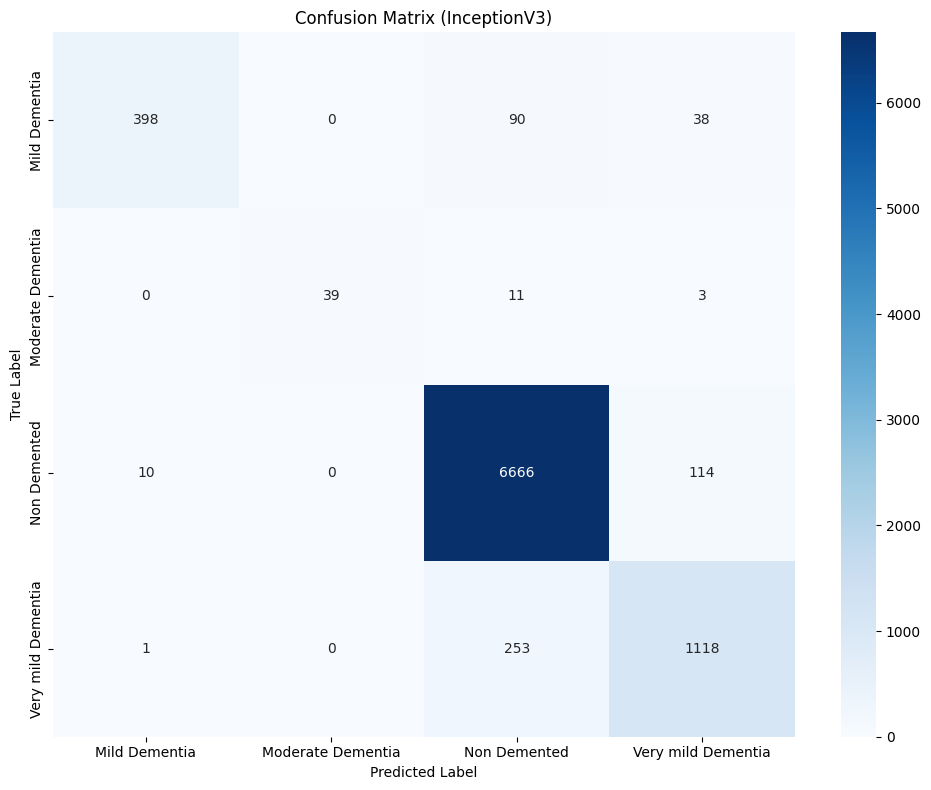


Evaluation complete!


In [13]:
#Cell 10: Final Evaluation

print("="*80)
print("FINAL EVALUATION (INCEPTION V3)")
print("="*80)

# Load best model
best_model = tf.keras.models.load_model(
    BEST_MODEL_SAVE_PATH,
    custom_objects={'focal_loss': focal_loss_fn(alpha=0.75, gamma=3.0)}
)

# Evaluate on all sets
train_loss, train_acc = best_model.evaluate(train_dataset_processed, verbose=0)
val_loss, val_acc = best_model.evaluate(val_dataset_processed, verbose=0)
test_loss, test_acc = best_model.evaluate(test_dataset_processed, verbose=0)

print(f"Training Accuracy:   {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy:        {test_acc:.4f}")

# Get predictions
y_true = np.concatenate([y.numpy() for _, y in test_dataset_processed], axis=0)
y_pred_probs = best_model.predict(test_dataset_processed, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Metrics
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

# Find early stage index
early_stage_idx = None
for i, name in enumerate(class_names):
    if 'Very mild' in name or 'very mild' in name:
        early_stage_idx = i
        break

if early_stage_idx is not None:
    early_stage_recall = f"{recall[early_stage_idx]:.4f}"
else:
    early_stage_recall = "N/A"

# Save summary
summary_text = f"""
MODEL: INCEPTION V3 TRANSFER LEARNING

Configuration:
- ImageNet weights (Transfer Learning)
- Improved Focal Loss (alpha=0.75, gamma=3.0)
- Two-stage training (Head + Fine-tuning)
- Image size: {IMG_SIZE}

Results:
- Training Accuracy:   {train_acc:.4f}
- Validation Accuracy: {val_acc:.4f}
- Test Accuracy:       {test_acc:.4f}

Per-Class Performance:
{classification_report(y_true, y_pred, target_names=class_names, digits=4)}

Early Detection Focus:
- Very Mild Dementia Recall: {early_stage_recall}
"""

print(summary_text)

with open('/content/drive/MyDrive/inceptionv3_summary.txt', 'w') as f:
    f.write(summary_text)

# Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (InceptionV3)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/inceptionv3_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nEvaluation complete!")
